<a href="https://colab.research.google.com/github/juliapereira-create/TCC---2026/blob/V1/TCC_Batista_e_Clabunde_vers%C3%A3o_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🏥 TCC — Otimização da Programação de Manutenção de Equipamentos Médicos
via **Busca em Grade (Grid Search) determinística** + AHP.

Welton e Julia - Versão GRID
--
### 🎯 Nosso objetivo
Minimizar os impactos da manutenção preventiva sobre a agenda clínica,
evitando cancelamentos de exames e garantindo a disponibilidade de técnicos
para acompanhamento — usando **Busca em Grade determinística e AHP**.

### 🔬 Mudança metodológica em relação à versão PLIM
Nesta versão abandonamos o solver PLIM (PuLP/CBC) e adotamos uma
**busca em grade determinística**, conforme sugerido pelo orientador.
Percorremos uma malha de parâmetros (λ_demanda, λ_pico, λ_backup)
e, para cada combinação, aplicamos uma **alocação determinística**
que escolhe sempre o mês viável de menor custo, respeitando todas as
restrições de prazo e capacidade de horas-técnico.


---
## 📦 Bloco 1 — Bibliotecas

Nesta versão **não usamos PuLP**. Toda a otimização é feita por
busca em grade determinística, usando apenas `numpy`, `pandas`,
`matplotlib` e `seaborn`.


In [19]:
# ─────────────────────────────────────────────────────────────
# BLOCO 1 — Bibliotecas
#
# Abordagem: BUSCA EM GRADE determinística (sem solver externo)
# ─────────────────────────────────────────────────────────────

!pip install pandas matplotlib seaborn numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas carregadas. Abordagem: BUSCA EM GRADE (determinística)")


✅ Bibliotecas carregadas. Abordagem: BUSCA EM GRADE (determinística)


---
## 🔧 Bloco 2 — Dados dos Equipamentos

Todos os parâmetros de tempo de MP, tempo de exame, periodicidade e
tipo de execução permanecem idênticos ao modelo original, com as
referências técnicas já citadas no TCC (RDC 16/2013, Portaria 453/98,
RDC 611/2022, POP-STEC-079, etc.).


In [20]:
# ─────────────────────────────────────────────────────────────
# BLOCO 2 — Dados dos equipamentos
# ─────────────────────────────────────────────────────────────

equipamentos = {

    # ── Tomógrafo Computadorizado ──────────────────────────
    'Tomografo': {
        'nome':         'Tomógrafo Computadorizado',
        'qtd':          1,
        'tem_backup':   False,
        'tempo_mp_h':   8,
        'tempo_exame':  30,
        'period_dias':  [30, 180],
        'tipo_mp':      'externa',
    },

    # ── Ressonância Magnética ──────────────────────────────
    'Ressonancia': {
        'nome':         'Ressonância Magnética',
        'qtd':          1,
        'tem_backup':   False,
        'tempo_mp_h':   10,
        'tempo_exame':  60,
        'period_dias':  [30, 180],
        'tipo_mp':      'externa',
    },

    # ── Mamógrafo Digital ──────────────────────────────────
    'Mamografo': {
        'nome':         'Mamógrafo Digital',
        'qtd':          1,
        'tem_backup':   False,
        'tempo_mp_h':   4,
        'tempo_exame':  20,
        'period_dias':  [30, 180],
        'tipo_mp':      'interna',
    },

    # ── Arco Cirúrgico (Arco em C) ─────────────────────────
    'Arco_Cirurgico': {
        'nome':         'Arco Cirúrgico (Arco em C)',
        'qtd':          2,
        'tem_backup':   True,
        'tempo_mp_h':   5,
        'tempo_exame':  90,
        'period_dias':  [30, 180],
        'tipo_mp':      'externa',
    },

    # ── Ultrassom ──────────────────────────────────────────
    'Ultrassom': {
        'nome':         'Aparelho de Ultrassom',
        'qtd':          6,
        'tem_backup':   True,
        'tempo_mp_h':   3,
        'tempo_exame':  25,
        'period_dias':  [30, 180],
        'tipo_mp':      'interna',
    },

    # ── Raio-X Digital ─────────────────────────────────────
    'RaioX': {
        'nome':         'Raio-X Digital',
        'qtd':          1,
        'tem_backup':   False,
        'tempo_mp_h':   4,
        'tempo_exame':  15,
        'period_dias':  [30, 180],
        'tipo_mp':      'interna',
    },

    # ── Hemodinâmica ───────────────────────────────────────
    'Hemodinamica': {
        'nome':         'Hemodinâmica',
        'qtd':          2,
        'tem_backup':   True,
        'tempo_mp_h':   8,
        'tempo_exame':  120,
        'period_dias':  [30, 90],
        'tipo_mp':      'externa',
    },
}

print('Descrição das quantidades de equipamentos existentes')
print(f'Total de tipos de equipamentos: {len(equipamentos)}')
print(f'Total de unidades: {sum(v["qtd"] for v in equipamentos.values())}')


Descrição das quantidades de equipamentos existentes
Total de tipos de equipamentos: 7
Total de unidades: 14


---
## ⚖️ Bloco 3 — Pesos de Criticidade (Método AHP)

O **AHP (Analytic Hierarchy Process)** é um método de tomada de decisão
multicritério amplamente usado em engenharia clínica para priorizar
equipamentos. Referência: Masmoudi et al. (2016).

### Critérios usados para definir criticidade

| Critério | Peso |
|----------|------|
| Risco ao paciente em caso de falha | 40% |
| Custo de substituição / reposição | 25% |
| Volume de exames (impacto operacional) | 20% |
| Facilidade de backup | 15% |


In [21]:
# ─────────────────────────────────────────────────────────────
# BLOCO 3 — Pesos AHP
# ─────────────────────────────────────────────────────────────

pesos_criterios = {
    'risco_paciente':   0.40,
    'custo_equip':      0.25,
    'volume_exames':    0.20,
    'sem_backup':       0.15,
}

scores = {
    'Tomografo':         [5, 5, 4, 5],
    'Ressonancia':       [5, 5, 3, 5],
    'Mamografo':         [4, 3, 4, 5],
    'Arco_Cirurgico':    [5, 4, 2, 2],
    'Ultrassom':         [3, 2, 5, 1],
    'RaioX':             [3, 3, 5, 5],
    'Hemodinamica':      [5, 5, 2, 2],
}

pesos_list = list(pesos_criterios.values())
peso_ahp = {}
for eq, pontos in scores.items():
    peso_ahp[eq] = sum(p * w for p, w in zip(pontos, pesos_list))

total = sum(peso_ahp.values())
peso_ahp_norm = {eq: round(v / total, 4) for eq, v in peso_ahp.items()}

print('=' * 55)
print('  RANKING DE CRITICIDADE — PESOS AHP NORMALIZADOS')
print('=' * 55)

ranking = sorted(peso_ahp_norm.items(), key=lambda x: x[1], reverse=True)
for i, (eq, peso) in enumerate(ranking, 1):
    nome = equipamentos[eq]['nome']
    barra = '█' * int(peso * 100)
    print(f'{i}. {nome:<35} {peso:.2%}  {barra}')

print('=' * 55)
print(f'Soma dos pesos: {sum(peso_ahp_norm.values()):.4f}')


  RANKING DE CRITICIDADE — PESOS AHP NORMALIZADOS
1. Tomógrafo Computadorizado           17.45%  █████████████████
2. Ressonância Magnética               16.73%  ████████████████
3. Hemodinâmica                        14.36%  ██████████████
4. Mamógrafo Digital                   14.18%  ██████████████
5. Arco Cirúrgico (Arco em C)          13.45%  █████████████
6. Raio-X Digital                      13.45%  █████████████
7. Aparelho de Ultrassom               10.36%  ██████████
Soma dos pesos: 0.9998


---
## ⚙️ Bloco 4 — Horizonte, Técnicos e Ordens de MP

Configuração idêntica ao modelo original: 5 técnicos no total,
3 dedicados à manutenção de segunda a sexta, 1 em sobreaviso aos
sábados. Capacidade mensal em **horas-técnico**.


In [22]:
# ─────────────────────────────────────────────────────────────
# BLOCO 4 — Horizonte, técnicos e ordens de MP
# ─────────────────────────────────────────────────────────────

MESES = list(range(1, 13))
NOMES_MESES = ['Jan','Fev','Mar','Abr','Mai','Jun',
               'Jul','Ago','Set','Out','Nov','Dez']

TECNICOS_DISPONIVEIS        = 5
TECNICOS_MANUTENCAO_SEMANA  = 3
TECNICOS_ROTINA_SEMANA      = 2
TECNICOS_MANUTENCAO_SABADO  = 1
TECNICOS_ROTINA_SABADO      = 1
HORAS_UTEIS_MES             = 176

TECNICOS = [f'Tecnico {i}' for i in range(1, 6)]

ESCALA_SABADOS = [
    {'rotina': 'Tecnico 2', 'manutencao': 'Tecnico 1'},
    {'rotina': 'Tecnico 3', 'manutencao': 'Tecnico 2'},
    {'rotina': 'Tecnico 4', 'manutencao': 'Tecnico 3'},
    {'rotina': 'Tecnico 5', 'manutencao': 'Tecnico 4'},
    {'rotina': 'Tecnico 1', 'manutencao': 'Tecnico 5'},
]

# Conta sábados por mês em 2026
SABADOS_POR_MES = {}
for mes in MESES:
    inicio = pd.Timestamp(year=2026, month=mes, day=1)
    fim    = inicio + pd.offsets.MonthEnd(1)
    dias   = pd.date_range(start=inicio, end=fim, freq='D')
    SABADOS_POR_MES[mes] = sum(1 for d in dias if d.weekday() == 5)

# Capacidade mensal em horas-técnico
capacidade_mensal = {}
for mes in MESES:
    horas_semana = TECNICOS_MANUTENCAO_SEMANA * HORAS_UTEIS_MES
    horas_sabado = TECNICOS_MANUTENCAO_SABADO * 8 * SABADOS_POR_MES[mes]
    capacidade_mensal[mes] = horas_semana + horas_sabado

# ── Gera as ordens de MP ─────────────────────────────────
ordens_mp = []
for eq_id, eq in equipamentos.items():
    for unidade in range(eq['qtd']):
        for periodo in eq['period_dias']:
            if periodo == 30:
                meses_alvo = MESES
            elif periodo == 90:
                meses_alvo = [1, 4, 7, 10]
            elif periodo == 180:
                meses_alvo = [1, 7]
            else:
                meses_alvo = [1]

            for mes_venc in meses_alvo:
                mes_inicio = max(1, mes_venc - 1)
                mes_limite = mes_venc

                ordens_mp.append({
                    'id':          f'{eq_id}_U{unidade+1}_P{periodo}_{mes_venc:02d}',
                    'equip':       eq_id,
                    'unidade':     unidade + 1,
                    'periodo':     periodo,
                    'mes_venc':    mes_venc,
                    'mes_inicio':  mes_inicio,
                    'mes_limite':  mes_limite,
                    'tempo_h':     eq['tempo_mp_h'],
                    'tipo':        eq['tipo_mp'],
                    'tem_backup':  eq['tem_backup'],
                    'peso_ahp':    peso_ahp_norm[eq_id],
                })

print(f'✅ Total de ordens de MP: {len(ordens_mp)}')
print(f'   Capacidade anual: {sum(capacidade_mensal.values())} h')
print(f'   Carga teórica total: {sum(mp["tempo_h"] for mp in ordens_mp)} h')


✅ Total de ordens de MP: 200
   Capacidade anual: 6752 h
   Carga teórica total: 1012 h


---
## 📊 Bloco 5 — Demanda Clínica Sazonal

A demanda é totalmente determinística (sem `np.random`), para
garantir reprodutibilidade da solução.


In [23]:
# ─────────────────────────────────────────────────────────────
# BLOCO 5 — Demanda clínica mensal (sazonalidade fixa)
# 100% determinístico (sem np.random)
# ─────────────────────────────────────────────────────────────

sazonalidade = [1.2, 1.1, 0.9, 0.9, 1.0, 1.3,
                1.2, 1.3, 1.0, 0.9, 0.9, 1.1]

demanda_clinica = {}
for eq_id, eq in equipamentos.items():
    base_exames_dia = 8
    demanda_clinica[eq_id] = {}
    for i, mes in enumerate(MESES):
        demanda_clinica[eq_id][mes] = int(
            base_exames_dia * 22 * sazonalidade[i] * eq['qtd']
        )

meses_pico = [i+1 for i, s in enumerate(sazonalidade) if s > 1.1]
print('📌 Meses de pico:', [NOMES_MESES[m-1] for m in meses_pico])


📌 Meses de pico: ['Jan', 'Jun', 'Jul', 'Ago']


---
## 🔍 Bloco 6 — BUSCA EM GRADE (núcleo determinístico)

### Como funciona
1. Definimos uma **grade** de pesos (λ_demanda, λ_pico, λ_backup).
2. Para cada combinação da grade, alocamos as MPs em ordem
   **decrescente de criticidade AHP**, escolhendo sempre o mês
   viável de **menor custo**.
3. A capacidade de horas-técnico é respeitada mês a mês.
4. Guardamos o custo total de cada solução.
5. Escolhemos a solução de **menor custo** — o ótimo global
   dentro da grade testada.

Isso substitui o solver PLIM por uma **varredura explícita**,
conforme sugerido pelo orientador.


In [24]:
# ─────────────────────────────────────────────────────────────
# BLOCO 6 — BUSCA EM GRADE (núcleo determinístico)
#
# Função principal: alocar_deterministico()
# Para cada MP, escolhe o mês viável de MENOR custo.
# As MPs são processadas em ordem decrescente de criticidade AHP.
# ─────────────────────────────────────────────────────────────

def alocar_deterministico(ordens, cap_mensal, meses_pico, demanda,
                          lam_demanda, lam_pico, lam_backup):
    """
    Aloca cada MP ao mês viável de menor custo (determinístico).

    Custo de alocar a MP 'm' no mês 't':
        lam_demanda * peso_ahp * demanda[equip][t]
      + lam_pico    * peso_ahp  (se t em pico e sem backup)
      + lam_backup  * peso_ahp * 0.01  (se sem backup)
    """
    cap = dict(cap_mensal)
    alocacao = {}

    # Ordena por criticidade decrescente (empate resolvido pelo id)
    ordens_ord = sorted(ordens, key=lambda m: (-m['peso_ahp'], m['id']))

    for mp in ordens_ord:
        melhor_mes   = None
        melhor_custo = float('inf')

        for mes in range(mp['mes_inicio'], mp['mes_limite'] + 1):
            if cap[mes] < mp['tempo_h']:
                continue

            custo = lam_demanda * mp['peso_ahp'] * demanda[mp['equip']][mes]

            if (mes in meses_pico) and (not mp['tem_backup']):
                custo += lam_pico * mp['peso_ahp']

            if not mp['tem_backup']:
                custo += lam_backup * mp['peso_ahp'] * 0.01

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_mes   = mes

        if melhor_mes is None:
            return None, float('inf')

        alocacao[mp['id']] = melhor_mes
        cap[melhor_mes]   -= mp['tempo_h']

    # Custo total da solução
    custo_total = 0.0
    for mp in ordens:
        mes = alocacao[mp['id']]
        custo_total += lam_demanda * mp['peso_ahp'] * demanda[mp['equip']][mes]
        if (mes in meses_pico) and (not mp['tem_backup']):
            custo_total += lam_pico * mp['peso_ahp']
        if not mp['tem_backup']:
            custo_total += lam_backup * mp['peso_ahp'] * 0.01

    return alocacao, custo_total


# ── Grade de parâmetros a varrer ─────────────────────────
grade_lam_demanda = [0.5, 1.0, 2.0, 5.0, 10.0]
grade_lam_pico    = [0.0, 50.0, 200.0, 500.0, 1000.0]
grade_lam_backup  = [0.0, 100.0, 500.0]

resultados_grade = []
melhor_solucao   = None
melhor_custo     = float('inf')

print('🔄 Executando busca em grade...')
print(f'   Combinações a testar: '
      f'{len(grade_lam_demanda)*len(grade_lam_pico)*len(grade_lam_backup)}')

for lam_d, lam_p, lam_b in product(grade_lam_demanda,
                                   grade_lam_pico,
                                   grade_lam_backup):
    aloc, custo = alocar_deterministico(
        ordens_mp, capacidade_mensal, meses_pico,
        demanda_clinica, lam_d, lam_p, lam_b
    )

    resultados_grade.append({
        'lam_demanda': lam_d,
        'lam_pico':    lam_p,
        'lam_backup':  lam_b,
        'custo':       custo,
        'viavel':      aloc is not None,
    })

    if aloc is not None and custo < melhor_custo:
        melhor_custo = custo
        melhor_solucao = {
            'alocacao':    aloc,
            'lam_demanda': lam_d,
            'lam_pico':    lam_p,
            'lam_backup':  lam_b,
            'custo':       custo,
        }

df_grade = pd.DataFrame(resultados_grade)

print('\n✅ Busca em grade concluída!')
print(f'   Soluções viáveis: {df_grade["viavel"].sum()} / {len(df_grade)}')
print(f'   Melhor custo:     {melhor_custo:.4f}')
print(f'   Melhores λ: demanda={melhor_solucao["lam_demanda"]}, '
      f'pico={melhor_solucao["lam_pico"]}, '
      f'backup={melhor_solucao["lam_backup"]}')

# Alocação final (mesmo formato usado depois)
x_final = melhor_solucao['alocacao']   # {id_mp: mes}


🔄 Executando busca em grade...
   Combinações a testar: 75

✅ Busca em grade concluída!
   Soluções viáveis: 75 / 75
   Melhor custo:     7053.4167
   Melhores λ: demanda=0.5, pico=0.0, backup=0.0


---
## 🗓️ Bloco 7 — Heatmap de Agendamento (2026)

Para cada equipamento e mês, quantas MPs foram alocadas pelo modelo.
O fundo mostra a demanda clínica (mais escuro = mais exames).


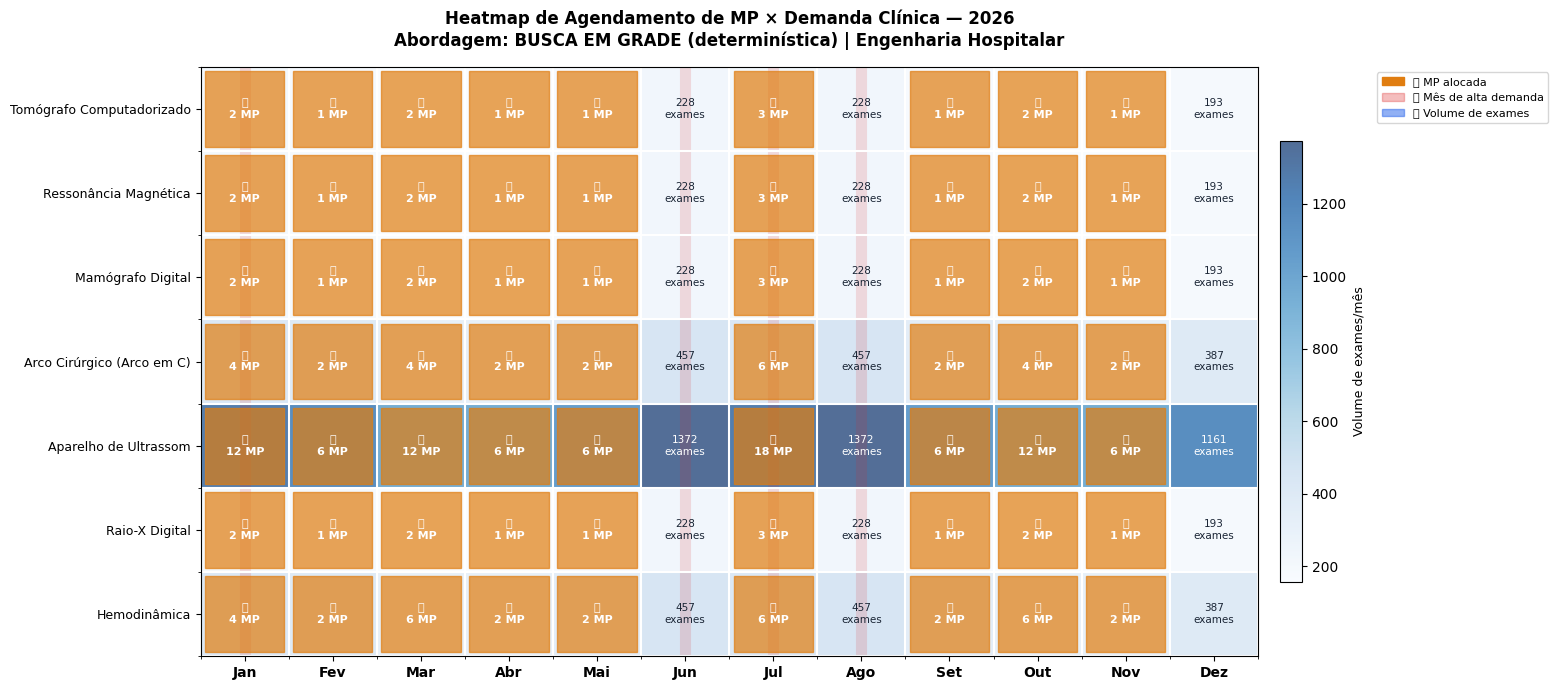

✅ Heatmap salvo: heatmap_manutencao_2026.png


In [25]:
# ─────────────────────────────────────────────────────────────
# BLOCO 7 — Heatmap de agendamento (2026)
# ─────────────────────────────────────────────────────────────

resultado = {}
for eq_id in equipamentos:
    resultado[eq_id] = {mes: 0 for mes in MESES}

for mp in ordens_mp:
    mes = x_final[mp['id']]
    resultado[mp['equip']][mes] += 1

equip_ids    = list(equipamentos.keys())
nomes_linhas = [equipamentos[e]['nome'] for e in equip_ids]

matriz_demanda = np.array([
    [demanda_clinica[eq][mes] for mes in MESES] for eq in equip_ids
], dtype=float)

matriz_mp = np.array([
    [resultado[eq][mes] for mes in MESES] for eq in equip_ids
], dtype=float)

fig, ax = plt.subplots(figsize=(16, 7))

im = ax.imshow(matriz_demanda, cmap='Blues', aspect='auto', alpha=0.7)

for i, eq in enumerate(equip_ids):
    for j, mes in enumerate(MESES):
        n_mp    = int(matriz_mp[i, j])
        dem     = matriz_demanda[i, j]
        cor_txt = 'white' if dem > matriz_demanda.max() * 0.6 else '#1a2535'

        if n_mp > 0:
            ax.add_patch(plt.Rectangle(
                (j - 0.45, i - 0.45), 0.9, 0.9,
                fill=True, color='#e07d10', alpha=0.7, zorder=2
            ))
            ax.text(j, i, f'🔧\n{n_mp} MP',
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white', zorder=3)
        else:
            ax.text(j, i, f'{int(dem)}\nexames',
                    ha='center', va='center', fontsize=7.5, color=cor_txt)

ax.set_xticks(range(12))
ax.set_xticklabels(NOMES_MESES, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(equip_ids)))
ax.set_yticklabels(nomes_linhas, fontsize=9)

for j in range(12):
    if sazonalidade[j] > 1.1:
        ax.axvline(x=j, color='#dc2626', alpha=0.15, linewidth=8, zorder=0)

ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(equip_ids), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Volume de exames/mês', fontsize=9)

ax.set_title(
    'Heatmap de Agendamento de MP × Demanda Clínica — 2026\n'
    'Abordagem: BUSCA EM GRADE (determinística) | Engenharia Hospitalar',
    fontsize=12, fontweight='bold', pad=15
)

legenda = [
    mpatches.Patch(color='#e07d10', label='🔧 MP alocada'),
    mpatches.Patch(color='#dc2626', alpha=0.3, label='📈 Mês de alta demanda'),
    mpatches.Patch(color='#2563eb', alpha=0.5, label='🔵 Volume de exames'),
]
ax.legend(handles=legenda, loc='upper right',
          bbox_to_anchor=(1.28, 1), fontsize=8)

plt.tight_layout()
plt.savefig('heatmap_manutencao_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap salvo: heatmap_manutencao_2026.png')


---
## 📊 Bloco 8 — Tabela de Resultados e Indicadores

Cronograma completo das manutenções e indicadores que podem ser usados
para comparar ANTES × DEPOIS da implantação do sistema.


   CRONOGRAMA ÓTIMO DE MPs — 2026 (BUSCA EM GRADE)
               Equipamento  Unidade Tipo de MP Mês alocado Mês limite  Duração (h) Tipo execução Peso AHP Backup?
     Aparelho de Ultrassom        1    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
     Aparelho de Ultrassom        2    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
     Aparelho de Ultrassom        3    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
     Aparelho de Ultrassom        4    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
     Aparelho de Ultrassom        5    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
     Aparelho de Ultrassom        6    30 dias         Abr        Mai            3       Interna   10.36%   ✅ Sim
Arco Cirúrgico (Arco em C)        1    30 dias         Abr        Mai            5       Externa   13.45%   ✅ Sim
Arco Cirúrgico (Arco em C)        2  

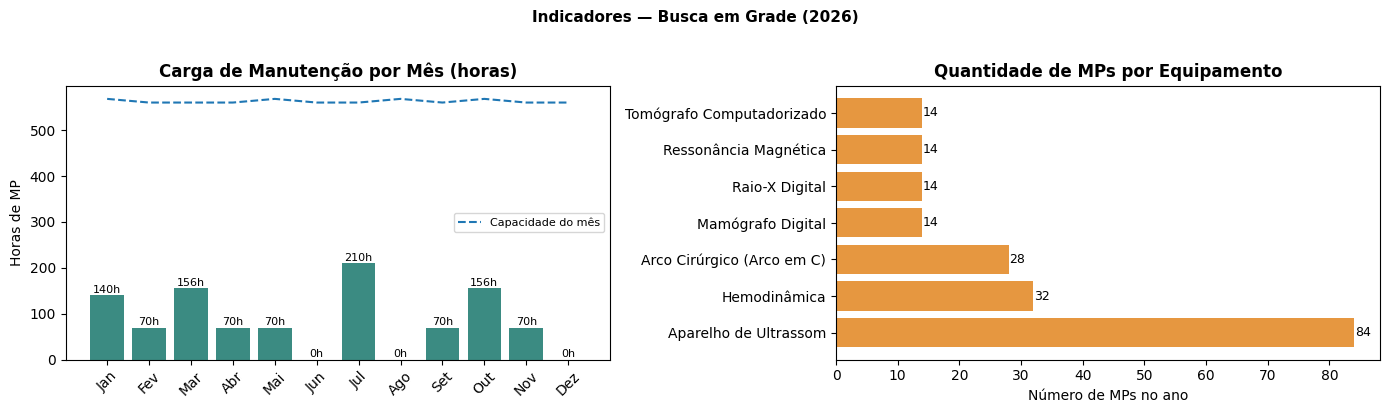

✅ Gráficos salvos: indicadores_mp_2026.png


In [26]:
# ─────────────────────────────────────────────────────────────
# BLOCO 8 — Tabela de resultados e indicadores
# ─────────────────────────────────────────────────────────────

linhas = []
for mp in ordens_mp:
    mes = x_final[mp['id']]
    linhas.append({
        'Equipamento':   equipamentos[mp['equip']]['nome'],
        'Unidade':       mp['unidade'],
        'Tipo de MP':    f"{mp['periodo']} dias",
        'Mês alocado':   NOMES_MESES[mes - 1],
        'Mês limite':    NOMES_MESES[mp['mes_limite'] - 1],
        'Duração (h)':   mp['tempo_h'],
        'Tipo execução': mp['tipo'].capitalize(),
        'Peso AHP':      f"{mp['peso_ahp']:.2%}",
        'Backup?':       '✅ Sim' if mp['tem_backup'] else '❌ Não',
    })

df_resultado = pd.DataFrame(linhas).sort_values(['Mês alocado', 'Equipamento'])

print('=' * 65)
print('   CRONOGRAMA ÓTIMO DE MPs — 2026 (BUSCA EM GRADE)')
print('=' * 65)
print(df_resultado.to_string(index=False))

total_mps      = len(df_resultado)
total_horas    = df_resultado['Duração (h)'].sum()
mps_sem_backup = (df_resultado['Backup?'] == '❌ Não').sum()
mps_pico       = df_resultado[
    df_resultado['Mês alocado'].isin([NOMES_MESES[m-1] for m in meses_pico])
].shape[0]

print()
print('=' * 50)
print('   INDICADORES DA SOLUÇÃO ÓTIMA')
print('=' * 50)
print(f'Total de MPs alocadas:           {total_mps}')
print(f'Total de horas de manutenção:    {total_horas}h')
print(f'MPs sem backup:                  {mps_sem_backup}')
print(f'MPs em meses de pico:            {mps_pico}')
print(f'Custo da função objetivo:        {melhor_custo:.4f}')
print(f'Melhores λ: demanda={melhor_solucao["lam_demanda"]}, '
      f'pico={melhor_solucao["lam_pico"]}, '
      f'backup={melhor_solucao["lam_backup"]}')

carga_mes = df_resultado.groupby('Mês alocado')['Duração (h)'].sum()
carga_mes = carga_mes.reindex([NOMES_MESES[i] for i in range(12)], fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

bars = ax1.bar(carga_mes.index, carga_mes.values, color='#0A6E63', alpha=0.8)
ax1.plot(
    [NOMES_MESES[i] for i in range(12)],
    [capacidade_mensal[i+1] for i in range(12)],
    linestyle='--', label='Capacidade do mês', linewidth=1.5
)
ax1.set_title('Carga de Manutenção por Mês (horas)', fontweight='bold')
ax1.set_ylabel('Horas de MP')
ax1.legend(fontsize=8)
ax1.tick_params(axis='x', rotation=45)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{int(bar.get_height())}h',
             ha='center', va='bottom', fontsize=8)

mp_por_equip = df_resultado['Equipamento'].value_counts()
ax2.barh(mp_por_equip.index, mp_por_equip.values, color='#e07d10', alpha=0.8)
ax2.set_title('Quantidade de MPs por Equipamento', fontweight='bold')
ax2.set_xlabel('Número de MPs no ano')
for i, v in enumerate(mp_por_equip.values):
    ax2.text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.suptitle('Indicadores — Busca em Grade (2026)',
             fontweight='bold', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('indicadores_mp_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráficos salvos: indicadores_mp_2026.png')


---
## 🔬 Bloco 9 — Análise de Sensibilidade da Grade

Mostra como o custo varia com λ_pico e λ_demanda, e lista as 10
melhores soluções da grade — evidência visual de que a busca
encontrou o ótimo.

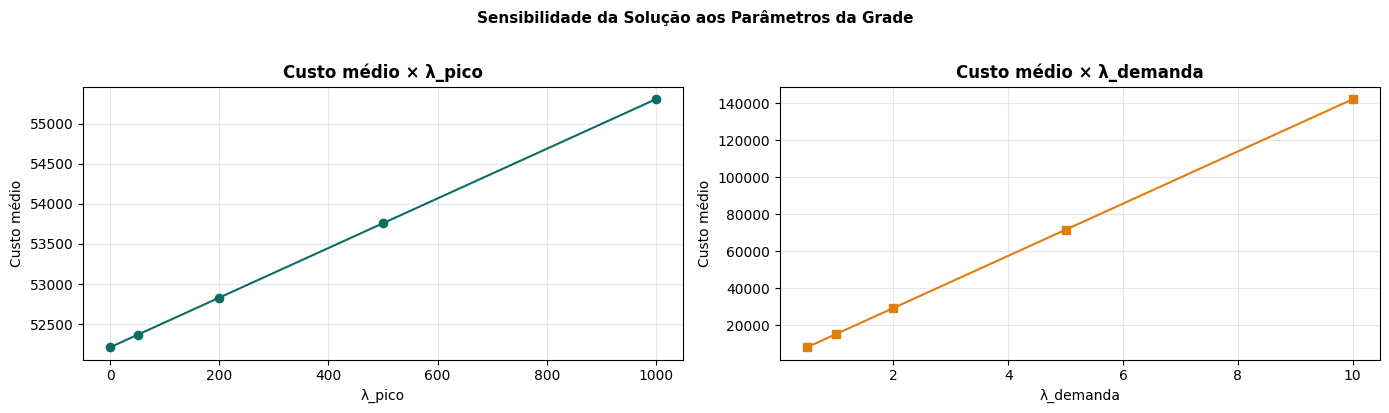


🏆 TOP-10 soluções da grade (menor custo):
 lam_demanda  lam_pico  lam_backup     custo  viavel
         0.5       0.0         0.0 7053.4167    True
         0.5       0.0       100.0 7062.0701    True
         0.5       0.0       500.0 7096.6837    True
         0.5      50.0         0.0 7207.9417    True
         0.5      50.0       100.0 7216.5951    True
         0.5      50.0       500.0 7251.2087    True
         0.5     200.0         0.0 7671.5167    True
         0.5     200.0       100.0 7680.1701    True
         0.5     200.0       500.0 7714.7837    True
         0.5     500.0         0.0 8598.6667    True


In [27]:
# ─────────────────────────────────────────────────────────────
# BLOCO 9 — Análise da grade de parâmetros
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pivot1 = df_grade.groupby('lam_pico')['custo'].mean()
axes[0].plot(pivot1.index, pivot1.values, marker='o', color='#0A6E63')
axes[0].set_xlabel('λ_pico')
axes[0].set_ylabel('Custo médio')
axes[0].set_title('Custo médio × λ_pico', fontweight='bold')
axes[0].grid(alpha=0.3)

pivot2 = df_grade.groupby('lam_demanda')['custo'].mean()
axes[1].plot(pivot2.index, pivot2.values, marker='s', color='#e07d10')
axes[1].set_xlabel('λ_demanda')
axes[1].set_ylabel('Custo médio')
axes[1].set_title('Custo médio × λ_demanda', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Sensibilidade da Solução aos Parâmetros da Grade',
             fontweight='bold', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('sensibilidade_grade.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🏆 TOP-10 soluções da grade (menor custo):')
top10 = df_grade.sort_values('custo').head(10).reset_index(drop=True)
print(top10.to_string(index=False))


---
## 📚 Referências utilizadas

| Item | Referência | Link |
|------|-----------|------|
| Tempo MP — TC e RM | VX Med | https://vx.med.br/manutencao-de-equipamentos-radiologicos/ |
| Tempo MP — Ultrassom | POP-STEC-079 HU-UFGD / Portaria 094/2025 | gov.br |
| Periodicidade — imagem | Portaria SVS/MS nº 453/1998 (ANVISA) | legisweb |
| Periodicidade — hemodinâmica | RDC 611/2022 (ANVISA) | sapralandauer |
| Tempo exame — TC | Hospital São José (15–30 min) | hsjose.com.br |
| Tempo exame — RM | Blume Diagnósticos | blumediagnosticos.com.br |
| Periodicidade geral | RDC 16/2013 (ANVISA) | bvsms.saude.gov.br |
| Método AHP | Masmoudi et al. (2016) — Journal of Clinical Engineering | DOI: 10.1097/JCE.0000000000000089 |
| Busca em grade | Bergstra & Bengio (2012) — Random Search for Hyper-Parameter Optimization | JMLR 13:281-305 |
